In [206]:
# Import library google.colab untuk berinteraksi dengan Google Drive
from google.colab import drive
# Mount Google Drive ke direktori '/content/drive' agar bisa mengakses file-file di dalamnya
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [207]:
# Definisikan path atau lokasi folder tempat data disimpan di Google Drive
path = "/content/drive/MyDrive/praktikum_ml/praktikum12/"

In [208]:
# Import library yang dibutuhkan
import numpy as np # Untuk operasi numerik, terutama array
import pandas as pd # Untuk manipulasi dan analisis data dalam bentuk DataFrame

# Import modul dari scikit-learn untuk machine learning
from sklearn.model_selection import train_test_split # Untuk membagi data menjadi set pelatihan dan pengujian
from sklearn.preprocessing import StandardScaler # Untuk melakukan penskalaan fitur (standardisasi)
from sklearn.decomposition import PCA # Untuk Principal Component Analysis (reduksi dimensi)
from sklearn.svm import SVC # Untuk Support Vector Classifier (model klasifikasi SVM)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Untuk evaluasi model

# Import library untuk visualisasi data
import matplotlib.pyplot as plt # Untuk membuat plot statis, interaktif, dan animasi
from mpl_toolkits.mplot3d import Axes3D # Untuk visualisasi plot 3D

# Atur ukuran default untuk semua plot matplotlib
plt.rcParams['figure.figsize'] = (8,6)

In [209]:
# Muat dataset dari file CSV ke dalam DataFrame pandas dengan nama 'cancer'
cancer = pd.read_csv(path + 'data/data.csv')

# Buat salinan DataFrame 'cancer' ke 'df' untuk pengerjaan lebih lanjut
df = cancer.copy()

# Tambahkan kolom 'target' ke DataFrame 'df'
# Kolom 'diagnosis' yang berisi 'M' (Malignant/Ganas) atau 'B' (Benign/Jinak) diubah menjadi nilai numerik:
# 'M' dipetakan ke 1 (positif, ganas)
# 'B' dipetakan ke 0 (negatif, jinak)
df['target'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Tampilkan 5 baris pertama dari DataFrame 'df' setelah penambahan kolom 'target'
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN,1


In [210]:
# Tampilkan ringkasan informasi dari DataFrame 'df'
# Ini termasuk jumlah entri non-null, tipe data setiap kolom, dan penggunaan memori
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [211]:
# Tampilkan statistik deskriptif dari kolom-kolom numerik dalam DataFrame 'df'
# Ini mencakup count, mean, std, min, 25%, 50%, 75%, dan max
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32,target
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN,0.372583
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN,0.483918
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN,0.000000
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN,0.000000
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN,0.000000
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN,1.000000
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN,1.000000


In [212]:
# Hitung jumlah nilai null (kosong) di setiap kolom DataFrame 'df'
# Ini membantu dalam mengidentifikasi kolom dengan data hilang
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [213]:
# Hitung jumlah baris duplikat dalam DataFrame 'df'
# Metode .sum() akan mengembalikan total baris yang merupakan duplikat
df.duplicated().sum()

np.int64(0)

In [214]:
# Tampilkan nama-nama kelas unik yang ada di kolom 'diagnosis' (M atau B)
print("Nama kelas:", df['diagnosis'].unique())
# Hitung frekuensi kemunculan setiap nilai unik di kolom 'target' (0 atau 1)
# Ini menunjukkan distribusi jumlah kasus jinak (0) dan ganas (1)
df['target'].value_counts()

Nama kelas: ['M' 'B']


,count
target,
0,357
1,212


In [215]:
# Hapus kolom 'id' dan 'Unnamed: 32' dari DataFrame 'df'
# Kolom 'id' tidak relevan untuk pemodelan, dan 'Unnamed: 32' berisi banyak nilai null.
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Definisikan fitur (X) dengan menghapus kolom 'diagnosis' dan 'target' dari DataFrame df yang sudah dibersihkan
X = df.drop(['diagnosis', 'target'], axis=1)
# Definisikan variabel target (y) sebagai kolom 'target'
y = df['target']

# Cetak bentuk (shape) dari X (jumlah baris, jumlah kolom) dan y (jumlah baris)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (569, 30)
Shape of y: (569,)


In [216]:
# Bagi data menjadi set pelatihan (training) dan pengujian (testing)
# X: fitur, y: target
# test_size=0.2: 20% data akan digunakan sebagai set pengujian
# random_state=42: untuk memastikan hasil pembagian data selalu sama (reproducible)
# stratify=y: pembagian dilakukan secara proporsional berdasarkan distribusi kelas di 'y', memastikan rasio kelas yang sama di set train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cetak bentuk (shape) dari set pelatihan dan pengujian untuk fitur dan target
print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (455, 30)
Shape X_test: (114, 30)


In [217]:
# Inisialisasi StandardScaler untuk penskalaan fitur
# StandardScaler akan menormalkan fitur sehingga memiliki rata-rata 0 dan variansi 1
scaler = StandardScaler()

# Lakukan penskalaan pada data pelatihan (fit dan transform)
# .fit_transform() menghitung rata-rata dan standar deviasi dari X_train, lalu mengaplikasikan transformasi
X_train_scaled = scaler.fit_transform(X_train)
# Lakukan penskalaan pada data pengujian (hanya transform)
# .transform() mengaplikasikan rata-rata dan standar deviasi yang sama yang dihitung dari X_train ke X_test
X_test_scaled = scaler.transform(X_test)

# Tampilkan 5 baris pertama dari data pelatihan yang sudah diskala
X_train_scaled[:5]

array([[ 5.18558727e-01,  8.91825791e-01,  4.24631702e-01,
         3.83925436e-01, -9.74743706e-01, -6.89771505e-01,
        -6.88586446e-01, -3.98175254e-01, -1.03915470e+00,
        -8.25056321e-01, -1.09317755e-01, -5.59755400e-02,
        -2.10096206e-01, -1.59132582e-02, -1.00518399e+00,
        -9.11941990e-01, -6.62815884e-01, -6.52561081e-01,
        -7.01889114e-01, -2.75393571e-01,  5.79797697e-01,
         1.31324246e+00,  4.66908134e-01,  4.45982711e-01,
        -5.96154777e-01, -6.34722227e-01, -6.10227299e-01,
        -2.35743918e-01,  5.45663235e-02,  2.18367276e-02],
       [-5.16364088e-01, -1.63971029e+00, -5.41348716e-01,
        -5.42961327e-01,  4.76219058e-01, -6.31833818e-01,
        -6.04281166e-01, -3.03074908e-01,  5.21543093e-01,
        -4.54522896e-01, -6.04377961e-01, -1.00104604e+00,
        -5.85429002e-01, -4.93453793e-01,  4.03212009e-01,
        -7.68173276e-01, -4.79187222e-01,  1.14508478e-01,
        -1.42950761e-01, -5.77397732e-01, -5.82458953e-

In [218]:
# Inisialisasi model Support Vector Classifier (SVC) tanpa PCA
# kernel='rbf': menggunakan Radial Basis Function sebagai fungsi kernel
# gamma='scale': mengatur koefisien kernel secara otomatis
# random_state=42: untuk reproduktibilitas hasil
svm_no_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
# Latih model SVM menggunakan data pelatihan yang sudah diskala
svm_no_pca.fit(X_train_scaled, y_train)

# Lakukan prediksi pada data pengujian yang sudah diskala
y_pred_no_pca = svm_no_pca.predict(X_test_scaled)

# Hitung akurasi model
acc_no_pca = accuracy_score(y_test, y_pred_no_pca)
print("Akurasi SVM tanpa PCA:", acc_no_pca)

# Definisikan nama-nama kelas untuk laporan klasifikasi
class_names = ['Benign', 'Malignant']

# Tampilkan laporan klasifikasi yang berisi precision, recall, f1-score, dan support untuk setiap kelas
print("\nClassification Report (tanpa PCA):")
print(classification_report(y_test, y_pred_no_pca, target_names=class_names))

Akurasi SVM tanpa PCA: 0.9736842105263158

Classification Report (tanpa PCA):
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [219]:
# Inisialisasi model Principal Component Analysis (PCA) dengan 3 komponen utama
pca = PCA(n_components=3)

# Terapkan PCA pada data pelatihan yang sudah diskala (fit dan transform)
# .fit_transform() menghitung komponen utama dari X_train_scaled, lalu mengubah X_train_scaled ke ruang PC
X_train_pca = pca.fit_transform(X_train_scaled)
# Terapkan PCA pada data pengujian yang sudah diskala (hanya transform)
# .transform() mengaplikasikan komponen utama yang sama yang dihitung dari X_train_scaled ke X_test_scaled
X_test_pca = pca.transform(X_test_scaled)

# Cetak bentuk (shape) dari data pelatihan dan pengujian setelah PCA
print("Shape X_train_pca:", X_train_pca.shape)
print("Shape X_test_pca:", X_test_pca.shape)

Shape X_train_pca: (455, 3)
Shape X_test_pca: (114, 3)


In [220]:
# Ambil rasio variansi yang dijelaskan oleh setiap komponen utama PCA
explained_var = pca.explained_variance_ratio_

# Cetak rasio variansi yang dijelaskan untuk setiap komponen
print("Explained Variance Ratio tiap komponen:", explained_var)
# Cetak total variansi yang dijelaskan oleh 3 komponen utama pertama
print("Total variansi yang dijelaskan 3 komponen pertama:", explained_var.sum())

Explained Variance Ratio tiap komponen: [0.44593522 0.18545255 0.09584641]
Total variansi yang dijelaskan 3 komponen pertama: 0.7272341886241546


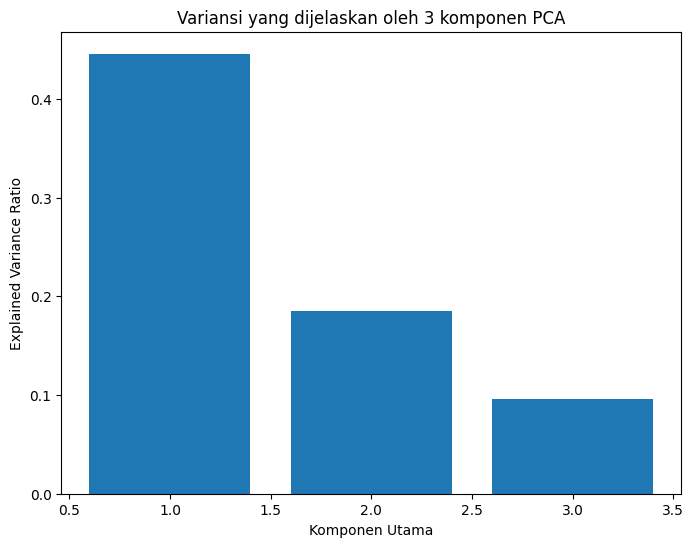

In [221]:
# Buat bar plot untuk memvisualisasikan explained variance ratio dari 3 komponen utama PCA
# Sumbu x: Komponen Utama (1, 2, 3)
# Sumbu y: Explained Variance Ratio
plt.bar([1,2,3], explained_var)
plt.xlabel('Komponen Utama') # Label sumbu x
plt.ylabel('Explained Variance Ratio') # Label sumbu y
plt.title('Variansi yang dijelaskan oleh 3 komponen PCA') # Judul plot
plt.show() # Tampilkan plot

In [222]:
# Inisialisasi model Support Vector Classifier (SVC) dengan PCA
# kernel='rbf': menggunakan Radial Basis Function sebagai fungsi kernel
# gamma='scale': mengatur koefisien kernel secara otomatis
# random_state=42: untuk reproduktibilitas hasil
svm_pca = SVC(kernel='rbf', gamma='scale', random_state=42)
# Latih model SVM menggunakan data pelatihan yang sudah melalui PCA
svm_pca.fit(X_train_pca, y_train)

# Lakukan prediksi pada data pengujian yang sudah melalui PCA
y_pred_pca = svm_pca.predict(X_test_pca)

# Hitung akurasi model SVM dengan PCA
acc_pca = accuracy_score(y_test, y_pred_pca)

# Cetak akurasi model
print(f"Akurasi SVM dengan PCA (3 komponen): {acc_pca:.4f}")

# Definisikan nama-nama kelas untuk laporan klasifikasi
# Sesuai dengan mapping: 0=Benign, 1=Malignant
class_names = ['Benign (0)', 'Malignant (1)']

# Tampilkan laporan klasifikasi yang berisi precision, recall, f1-score, dan support untuk setiap kelas
print("\nClassification Report (dengan PCA):")
print(classification_report(y_test, y_pred_pca, target_names=class_names))

Akurasi SVM dengan PCA (3 komponen): 0.9561

Classification Report (dengan PCA):
               precision    recall  f1-score   support

   Benign (0)       0.94      1.00      0.97        72
Malignant (1)       1.00      0.88      0.94        42

     accuracy                           0.96       114
    macro avg       0.97      0.94      0.95       114
 weighted avg       0.96      0.96      0.96       114



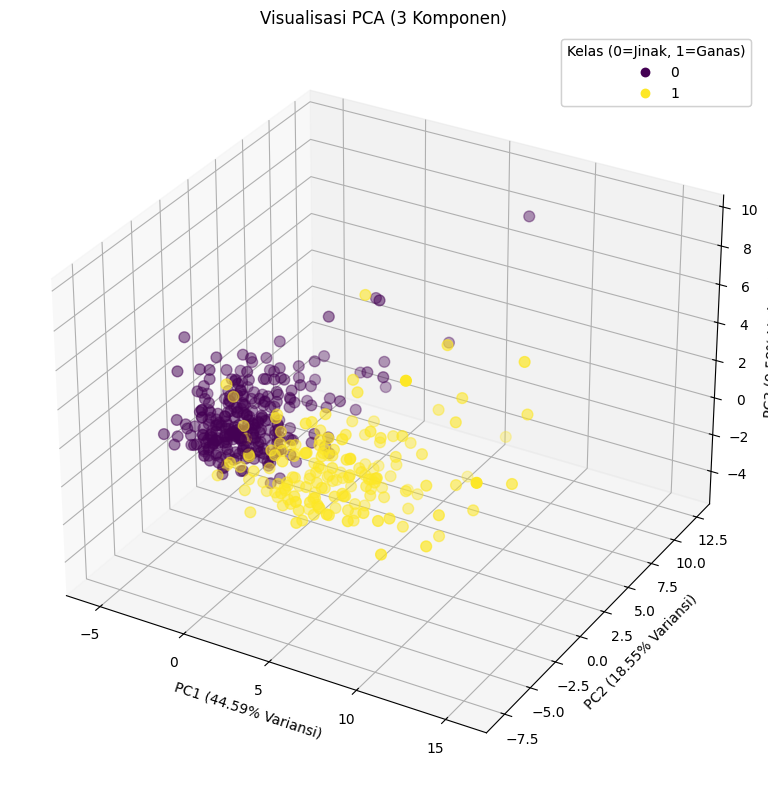

In [223]:
# Plot Visualisasi 3D data hasil PCA (PC1, PC2, dan PC3)
# Inisialisasi figure untuk plot
fig = plt.figure(figsize=(10, 8))
# Tambahkan subplot 3D ke figure
ax = fig.add_subplot(111, projection='3d')

# Buat scatter plot 3D
# X_train_pca[:, 0]: Komponen Utama 1 sebagai sumbu X
# X_train_pca[:, 1]: Komponen Utama 2 sebagai sumbu Y
# X_train_pca[:, 2]: Komponen Utama 3 sebagai sumbu Z
# c=y_train: Warna titik berdasarkan kelas target (y_train)
# cmap='viridis': Skema warna yang digunakan
# s=60: Ukuran titik
scatter = ax.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    X_train_pca[:, 2],
    c=y_train,
    cmap='viridis',
    s=60
)

# Setel judul plot
ax.set_title('Visualisasi PCA (3 Komponen)')
# Setel label untuk sumbu X, Y, dan Z, termasuk persentase variansi yang dijelaskan oleh setiap komponen
ax.set_xlabel('PC1 ({:.2f}% Variansi)'.format(explained_var[0]*100))
ax.set_ylabel('PC2 ({:.2f}% Variansi)'.format(explained_var[1]*100))
ax.set_zlabel('PC3 ({:.2f}% Variansi)'.format(explained_var[2]*100))

# Buat legenda untuk plot
# scatter.legend_elements() secara otomatis membuat elemen legenda dari scatter plot
legend1 = ax.legend(
    *scatter.legend_elements(),
    title='Kelas (0=Jinak, 1=Ganas)'
)

# Tambahkan legenda ke plot
ax.add_artist(legend1)
# Sesuaikan tata letak plot agar tidak ada label yang tumpang tindih
plt.tight_layout()
# Tampilkan plot
plt.show()

In [224]:
# Buat DataFrame pandas untuk membandingkan kinerja model
comparisom = pd.DataFrame({
    'Model': ['SVM Tanpa PCA', 'SVM Dengan PCA (3 Komponen)'], # Nama model
    'Jumlah Fitur': [X_train_scaled.shape[1], X_train_pca.shape[1]], # Jumlah fitur yang digunakan oleh setiap model
    'Akurasi': [acc_no_pca, acc_pca], # Akurasi yang dicapai oleh setiap model
    'Variansi Total PCA': [None, explained_var.sum()] # Total variansi yang dijelaskan oleh PCA (None jika tanpa PCA)
})

# Tampilkan DataFrame perbandingan
comparisom

,Model,Jumlah Fitur,Akurasi,Variansi Total PCA
0,SVM Tanpa PCA,30,0.973684,NaN
1,SVM Dengan PCA (3 Komponen),3,0.956140,0.727234


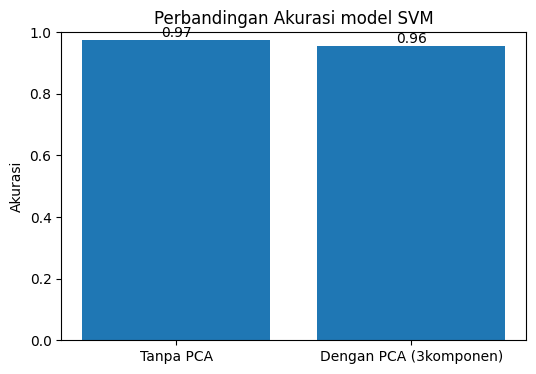

In [225]:
# Buat figure untuk plot dengan ukuran tertentu
plt.figure(figsize=(6,4))
# Buat bar chart untuk membandingkan akurasi model SVM
# Sumbu X: Nama model ('Tanpa PCA', 'Dengan PCA (3komponen)')
# Sumbu Y: Nilai akurasi (acc_no_pca, acc_pca)
plt.bar(['Tanpa PCA', 'Dengan PCA (3komponen)'], [acc_no_pca, acc_pca])
# Setel judul plot
plt.title('Perbandingan Akurasi model SVM')
# Setel label sumbu Y
plt.ylabel('Akurasi')
# Setel batas rentang sumbu Y dari 0 hingga 1 (umum untuk akurasi)
plt.ylim(0, 1)
# Tambahkan nilai akurasi di atas setiap bar
for i, v in enumerate([acc_no_pca, acc_pca]):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center') # Teks nilai akurasi dibulatkan 2 desimal, sedikit di atas bar
# Tampilkan plot
plt.show()